In [110]:
import numpy as np

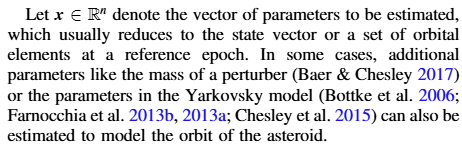

In [111]:
import requests

response = requests.get("https://data.minorplanetcenter.net/api/get-orb", json={"desig": "Eros"})

if response.ok:
    orb = response.json()[0]['mpc_orb']
else:
    print("Error: ", response.status_code, response.content)

In [112]:
print(orb[0].keys())
print(orb[0]['CAR'].keys())
print(orb[0]['COM'].keys())
print(orb[0]['categorization'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['epoch_data'].keys())
print(orb[0]['magnitude_data'].keys())
print(orb[0]['moid_data'].keys())
print(orb[0]['non_grav_booleans'].keys())
print(orb[0]['orbit_fit_statistics'].keys())
print(orb[0]['software_data'].keys())
print(orb[0]['system_data'].keys())

dict_keys(['CAR', 'COM', 'categorization', 'designation_data', 'epoch_data', 'magnitude_data', 'moid_data', 'non_grav_booleans', 'orbit_fit_statistics', 'software_data', 'system_data'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['object_type_int', 'object_type_str', 'orbit_subtype_int', 'orbit_subtype_str', 'orbit_type_int', 'orbit_type_str'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional_designation', 'packed_secondary_provisional_designations', 'permid', 'unpacked_primary_provisional_designation', 'unpacked_secondary_provisional_designations'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional

In [113]:
print(orb[0]['system_data']['refframe'])
print(orb[0]['system_data']['refsys'])

ICRF
Ecliptic


In [114]:
orbital_elements = orb[0]['CAR']['coefficient_values']
x = np.array(orbital_elements)

In [115]:
AU_to_km = 1.495978707e8
day_to_sec = 86400.0

In [116]:
x[:3] *= AU_to_km
x[3:] *= AU_to_km / day_to_sec

In [117]:
print(x)

[ 1.20144699e+08  1.48565328e+08  3.49924625e+07 -2.41244768e+01
  1.30481711e+01 -2.40794861e+00]


In [118]:
t0_mjd = orb[0]['epoch_data']['epoch']

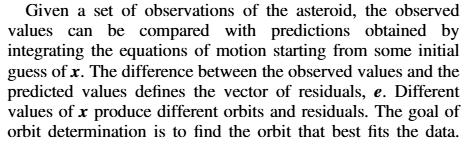

In [119]:
import spiceypy as sp

sp.kclear()

# The meta kernel file contains entries pointing to the following SPICE kernels, which the user needs to download.
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440.bsp
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_000101_260619_260323.bpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de431.tpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/asteroids/codes_300ast_20100725.tf
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/asteroids/codes_300ast_20100725.bsp
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00010.tpc

#   The following is the contents of a metakernel that was saved with
#   the name 'cassMetaK.txt'.
#   \begindata
#   KERNELS_TO_LOAD=(
#     'naif0012.tls',
#     'de440.bsp',
#     'earth_000101_260619_260323.bpc',
#     'earth_latest_high_prec.bpc',
#     'gm_de431.tpc',
#     'codes_300ast_20100725.bsp',
#     'codes_300ast_20100725.tf',
#     'pck00010.tpc',
#   )
#   \begintext

sp.furnsh("./planetaryMetaK.txt")

In [120]:
print(sp.ktotal('ALL'))

9


In [121]:
try:
    # Try to fetch the variable that is causing the crash
    val = sp.gdpool('TKFRAME_1900017_SPEC', 0, 1)
    print("Found frame variable:", val)
except Exception as e:
    print("Variable NOT found in pool! Your kernels are not loaded correctly.")
    print("Total kernels loaded:", sp.ktotal('ALL'))

Variable NOT found in pool! Your kernels are not loaded correctly.
Total kernels loaded: 9


In [122]:
help(sp.spkezr)

Help on function spkezr in module spiceypy.spiceypy:

spkezr(targ: str, et: Union[ndarray, float], ref: str, abcorr: str, obs: str) -> Union[Tuple[ndarray, float], Tuple[Iterable[ndarray], Iterable[float]]]
    Return the state (position and velocity) of a target body
    relative to an observing body, optionally corrected for light
    time (planetary aberration) and stellar aberration.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/spkezr_c.html

    :param targ: Target body name.
    :param et: Observer epoch in seconds past J2000 TDB.
    :param ref: Reference frame of output state vector.
    :param abcorr: Aberration correction flag.
    :param obs: Observing body name.
    :return:
            State of target in km and km/sec,
            One way light time between observer and target in seconds.



In [123]:
sun_radius = 695700 #km
sun_mu = 1.32712440018e11  # km^3/s^2

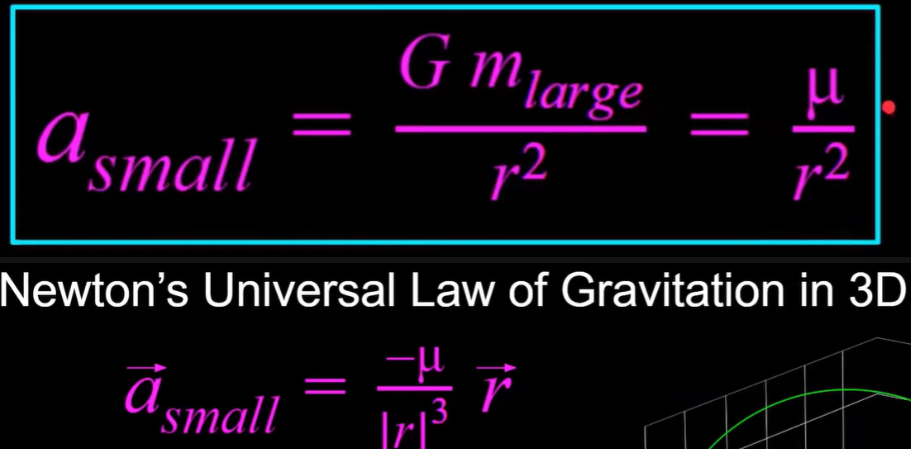

In [124]:
import numpy as np

![image.png](attachment:image.png)

In [125]:
import requests

response = requests.get("https://data.minorplanetcenter.net/api/get-orb", json={"desig": "Eros"})

if response.ok:
    orb = response.json()[0]['mpc_orb']
else:
    print("Error: ", response.status_code, response.content)

In [126]:
print(orb[0].keys())
print(orb[0]['CAR'].keys())
print(orb[0]['COM'].keys())
print(orb[0]['categorization'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['epoch_data'].keys())
print(orb[0]['magnitude_data'].keys())
print(orb[0]['moid_data'].keys())
print(orb[0]['non_grav_booleans'].keys())
print(orb[0]['orbit_fit_statistics'].keys())
print(orb[0]['software_data'].keys())
print(orb[0]['system_data'].keys())

dict_keys(['CAR', 'COM', 'categorization', 'designation_data', 'epoch_data', 'magnitude_data', 'moid_data', 'non_grav_booleans', 'orbit_fit_statistics', 'software_data', 'system_data'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['object_type_int', 'object_type_str', 'orbit_subtype_int', 'orbit_subtype_str', 'orbit_type_int', 'orbit_type_str'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional_designation', 'packed_secondary_provisional_designations', 'permid', 'unpacked_primary_provisional_designation', 'unpacked_secondary_provisional_designations'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional

In [127]:
print(orb[0]['system_data']['refframe'])
print(orb[0]['system_data']['refsys'])

ICRF
Ecliptic


In [128]:
orbital_elements = orb[0]['CAR']['coefficient_values']
x = np.array(orbital_elements)

In [129]:
AU_to_km = 1.495978707e8
day_to_sec = 86400.0

In [130]:
x[:3] *= AU_to_km
x[3:] *= AU_to_km / day_to_sec

In [131]:
print(x)

[ 1.20144699e+08  1.48565328e+08  3.49924625e+07 -2.41244768e+01
  1.30481711e+01 -2.40794861e+00]


In [132]:
t0_mjd = orb[0]['epoch_data']['epoch']

![image.png](attachment:image.png)

In [133]:
sp.kclear()

In [134]:

import spiceypy as sp

# The meta kernel file contains entries pointing to the following SPICE kernels, which the user needs to download.
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440.bsp
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_000101_260619_260323.bpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de431.tpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/asteroids/codes_300ast_20100725.tf
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00010.tpc

#   The following is the contents of a metakernel that was saved with
#   the name 'cassMetaK.txt'.
#   \begindata
#   KERNELS_TO_LOAD=(
#     'naif0012.tls',
#     'de440.bsp',
#     'earth_000101_260619_260323.bpc',
#     'earth_latest_high_prec.bpc',
#     'gm_de431.tpc',
#     'codes_300ast_20100725.tf',
#     'pck00010.tpc',
#   )
#   \begintext

sp.furnsh("./planetaryMetaK.txt")

In [135]:
print(sp.ktotal('ALL'))

9


In [136]:
help(sp.spkezr)

Help on function spkezr in module spiceypy.spiceypy:

spkezr(targ: str, et: Union[ndarray, float], ref: str, abcorr: str, obs: str) -> Union[Tuple[ndarray, float], Tuple[Iterable[ndarray], Iterable[float]]]
    Return the state (position and velocity) of a target body
    relative to an observing body, optionally corrected for light
    time (planetary aberration) and stellar aberration.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/spkezr_c.html

    :param targ: Target body name.
    :param et: Observer epoch in seconds past J2000 TDB.
    :param ref: Reference frame of output state vector.
    :param abcorr: Aberration correction flag.
    :param obs: Observing body name.
    :return:
            State of target in km and km/sec,
            One way light time between observer and target in seconds.



In [137]:
sun_radius = 695700 #km
sun_mu = 1.32712440018e11  # km^3/s^2

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

In [138]:
help(sp.bodvrd)

Help on function bodvrd in module spiceypy.spiceypy:

bodvrd(bodynm: str, item: str, maxn: int) -> Tuple[int, ndarray]
    Fetch from the kernel pool the double precision values
    of an item associated with a body.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/bodvrd_c.html

    :param bodynm: Body name.
    :param item:
                Item for which values are desired,
                ("RADII", "NUT_PREC_ANGLES", etc.)
    :param maxn: Maximum number of values that may be returned.
    :return: tuple of (dim, values)



In [139]:
print(sp.bodvrd('2000087', 'GM', 1)[1][0])

0.9899999999999999


In [140]:
def n_body_ode(t, state):
    
    r = state[:3]
    v = state[3:]
    
    r_norm = np.linalg.norm(r)
    a = -sun_mu * r / r_norm**3
    
    ssbs = [
        # (name, mu)
        
        # Terrestrial
        ('1', 22031.78000000002), # MERCURY
        ('2',   324858.592), # VENUS
        ('3',   398600.435), # EARTH
        ('4',    42828.375), # MARS
        
        # Satellites
        ('301',               4902.800), # MOON
        
        # Asteroids
        ('2000001',              63.129999999999995),
        ('2000002',              13.73),
        ('2000004',              17.28999999999999),
        
        ('2000010',            5.78),               # Hygiea
        ('2000015',            2.10),               # Eunomia
        ('2000016',            1.81),               # Psyche
        ('2000029',            0.86),               # Amphitrite
        ('2000052',            1.5899999999999999), # Europa
        ('2000065',            0.9099999999999999), # Cybele
        ('2000087',            0.9899999999999999), # Sylvia
        ('2000088',            1.02),               # Thisbe
        ('2000511',            2.259999999999999),  # Davida
        ('2000704',            2.189999999999999),  # Interamnia
        
        # Jovian
        ('5', 126712764.1),
        ('6',  37940585.2),
        ('7',  5794548.600000008),
        ('8', 6836527.100580023),
    ]
    
    for name, mu in ssbs:
        
        #i is planet, j is eros
        
        planet, _ = sp.spkezr(name, t, 'J2000', 'NONE', 'SUN')
        
        r_planet = planet[:3]
        r_ji = r - r_planet
        r_ji_norm = np.linalg.norm(r_ji)
        r_planet_norm = np.linalg.norm(r_planet)
        
        # subtracting pull due to sun
        a += -mu * (r_ji / r_ji_norm**3 + r_planet / r_planet_norm**3)
    
    return np.concatenate((v, a))

In [141]:
from scipy.integrate import solve_ivp

In [142]:
help(solve_ivp)

Help on function solve_ivp in module scipy.integrate._ivp.ivp:

solve_ivp(
    fun,
    t_span,
    y0,
    method='RK45',
    t_eval=None,
    dense_output=False,
    events=None,
    vectorized=False,
    args=None,
    **options
)
    Solve an initial value problem for a system of ODEs.

    This function numerically integrates a system of ordinary differential
    equations given an initial value::

        dy / dt = f(t, y)
        y(t0) = y0

    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.

    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex

In [143]:
def propagate(x, t0, ti):
    sol = solve_ivp(
        n_body_ode,
        (t0, ti),
        x,
        method = "DOP853",
        rtol=1e-12,
        atol=1e-12
    )
    
    return sol.y[:, -1]

In [144]:
response = requests.get("https://data.minorplanetcenter.net/api/get-obs", json={"desigs": ["Eros"], "output_format": ["ADES_DF"]})

if response.ok:
    obs_data = response.json()[0]['ADES_DF']
else:
    print("Error: ", response.status_code, response.content)


In [145]:
print(obs_data[0].keys())

dict_keys(['Obstype', 'artsat', 'astcat', 'band', 'com', 'ctr', 'dec', 'decstar', 'delay', 'deltadec', 'deltara', 'deprecated', 'disc', 'dist', 'doppler', 'exp', 'fltr', 'frq', 'localuse', 'logsnr', 'mag', 'mode', 'notes', 'nstars', 'nucmag', 'obscenter', 'obsid', 'obssubid', 'obstime', 'pa', 'permid', 'photap', 'photcat', 'pos1', 'pos2', 'pos3', 'poscov11', 'poscov12', 'poscov13', 'poscov22', 'poscov23', 'poscov33', 'precdec', 'precra', 'prectime', 'prog', 'provid', 'ra', 'rastar', 'rcv', 'ref', 'remarks', 'rmscorr', 'rmsdec', 'rmsdelay', 'rmsdist', 'rmsdoppler', 'rmsfit', 'rmsmag', 'rmspa', 'rmsra', 'rmstime', 'seeing', 'shapeocc', 'stn', 'subfmt', 'subfrm', 'sys', 'trkid', 'trkmpc', 'trksub', 'trx', 'unctime', 'vel1', 'vel2', 'vel3'])


In [146]:
for n, obs in enumerate(obs_data):
    obs['obstime'] = sp.str2et(obs['obstime'])
    obs_data[n] = obs

In [147]:
print(obs_data[0]['obstime'])
print(obs_data[1]['obstime'])

print(obs_data[-1]['stn'])

-3350513058.337489
-3350346081.6974645
W46


In [148]:
def angle_diff(a, b):
    return (a - b + np.pi) % (2*np.pi) - np.pi

In [149]:
t_epoch = sp.unitim(t0_mjd + 2400000.5, 'JDTDB', 'ET')  # MJD 61000 ≈ this date

for n, obs in enumerate(obs_data):
    if obs['obstime'] >= t_epoch:
        obs_index = n
        break
    
t0 = obs_data[obs_index]['obstime']
    
print(f"Propagating from {obs_index}th observation at {t0}")

Propagating from 16810th observation at 817011380.798867


In [150]:
x = propagate(x, 0.0, t0 - t_epoch)

In [151]:
R_earth = 6378.137 #km

In [152]:
ecl_to_j2000 = sp.pxform('ECLIPJ2000', 'J2000', t0)
x = np.concatenate([ecl_to_j2000 @ x[:3], ecl_to_j2000 @ x[3:]])

In [153]:
# stations.csv downloaded from https://www.minorplanetcenter.net/iau/lists/ObsCodes.html

import csv

def get_stn_properties(stn):
    
    with open('stations.csv', 'r', newline='\n') as stns:
        reader = csv.DictReader(stns)
        for row in reader:
            if row['Code'] == stn:
                return {
                    'Long.': float(row['Long.']) if row['Long.'].strip() != '' else None,
                    'cos': float(row['cos']) if row['cos'].strip() != '' else None,
                    'sin': float(row['sin']) if row['sin'].strip() != '' else None,
                }
    return None

In [154]:
def stn_to_ecef(stn, properties):
    
    lon = np.deg2rad(properties['Long.'])
    x = R_earth * properties['cos'] * np.cos(lon)
    y = R_earth * properties['cos'] * np.sin(lon)
    z = R_earth * properties['sin']
    
    return np.array([x, y, z])
    
            

In [155]:
help(sp.pxform)

Help on function pxform in module spiceypy.spiceypy:

pxform(fromstr: str, tostr: str, et: float) -> ndarray
    Return the matrix that transforms position vectors from one
    specified frame to another at a specified epoch.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/pxform_c.html

    :param fromstr: Name of the frame to transform from.
    :param tostr: Name of the frame to transform to.
    :param et: Epoch of the rotation matrix.
    :return: A rotation matrix.



In [156]:
twoseven = [obs for obs in obs_data[obs_index:] if obs['stn'] == '270'] # unistellar roving observatory whos coords change

print(twoseven[0]['pos1'], twoseven[0]['pos2'], twoseven[0]['pos3'])
print(twoseven[1]['pos1'], twoseven[1]['pos2'], twoseven[1]['pos3'])

13.87251 51.04915 0
7.24358 51.45864 0


In [157]:
R_earth_polar = 6356.7523

In [158]:
def get_observer_pos_j2000(stn, t_obs, properties):
    
    r_ecef = None
    
    if stn == '270': # unistellar roving observatory
        
        location = {
            'lon': properties['pos1'],
            'lat': properties['pos2'],
            'alt': properties['pos3']
        }
        
        
        flattening = R_earth - R_earth_polar / R_earth
        
        # converts to ECEF
        r_ecef = sp.georec(
            location['lon'] * sp.rpd(),
            location['lat'] * sp.rpd(),
            location['alt'] / 1000.0, # convert to km
            R_earth, flattening
        )
    
    else:
        
        r_ecef = stn_to_ecef(stn, properties)
        
    earth, _ = sp.spkezr('EARTH', t_obs, 'J2000', 'NONE', 'SUN')
    rot = sp.pxform('ITRF93', 'J2000', t_obs)
    r_obs_j2000 = rot @ r_ecef
    
    return earth[:3] + r_obs_j2000

In [159]:
c_km_s = 299792.458

In [160]:
from collections import Counter

print(Counter(obs.get('astcat') for obs in obs_data[obs_index:]))
print(Counter(obs.get('mode') for obs in obs_data[obs_index:]))
print(Counter(obs.get('stn') for obs in obs_data[obs_index:]))

Counter({'Gaia2': 585, 'Gaia3E': 462, 'ATLAS2': 70, 'UCAC4': 26, 'USNOA2': 20, 'Gaia3': 14})
Counter({'CCD': 1040, 'CMO': 137})
Counter({'270': 488, 'C40': 380, 'C23': 49, 'L65': 24, 'L76': 22, 'J51': 21, '233': 20, '703': 20, '006': 17, '160': 17, 'D29': 15, 'D04': 12, '122': 9, 'X33': 9, 'G96': 8, 'K74': 6, 'G17': 6, 'R61': 6, 'M22': 5, 'T08': 4, 'G11': 3, 'M59': 3, 'X76': 3, 'Y84': 3, 'M73': 3, 'G02': 3, 'X04': 3, 'K87': 3, 'R97': 3, '185': 3, 'T05': 3, 'L92': 3, 'W46': 3})


In [161]:
print(obs_data[obs_index+13]['rmsra'], obs_data[obs_index+13]['rmsdec']) # both are str


0.09 0.19


In [162]:
VFCCLookup = {
# (stn, astcat) : (ra, dec) arcsec 

# USNOA2.0 
('704', 'USNOA2')  : (0.63, 0.60),
('699', 'USNOA2')  : (0.62, 0.53),
('691', 'USNOA2')  : (0.30, 0.30),
('608', 'USNOA2')  : (0.61, 0.75),
('703', 'USNOA2')  : (0.69, 0.63),
('644', 'USNOA2')  : (0.29, 0.30),
('291', 'USNOA2')  : (0.46, 0.32),
('599', 'USNOA2')  : (0.39, 0.34),
('333', 'USNOA2')  : (0.55, 0.53),
('D35', 'USNOA2')  : (0.39, 0.38),

# USNOA1.0 
('704', 'USNOA1')  : (0.76, 0.73),
('691', 'USNOA1')  : (0.49, 0.46),

# USNOB1.0 
('699', 'USNOB1')  : (0.61, 0.54),
('644', 'USNOB1')  : (0.24, 0.20),
('691', 'USNOB1')  : (0.30, 0.28),
('291', 'USNOB1')  : (0.39, 0.26),

# UCAC1
('703', 'UCAC1')   : (0.63, 0.59),
('G96', 'UCAC1')   : (0.32, 0.27),
('E12', 'UCAC1')   : (0.50, 0.45),
('683', 'UCAC1')   : (0.79, 0.90),
('J75', 'UCAC1')   : (0.41, 0.37),
('106', 'UCAC1')   : (0.40, 0.39),
('143', 'UCAC1')   : (0.57, 0.47),

# UCAC2
('703', 'UCAC2')   : (0.63, 0.59),
('G96', 'UCAC2')   : (0.32, 0.27),
('E12', 'UCAC2')   : (0.50, 0.45),
('683', 'UCAC2')   : (0.79, 0.90),
('J75', 'UCAC2')   : (0.41, 0.37),
('106', 'UCAC2')   : (0.40, 0.39),
('143', 'UCAC2')   : (0.57, 0.47),

# Gaia2
('T14', 'Gaia2')   : (0.10, 0.10),
('T12', 'Gaia2')   : (0.10, 0.10),
('T09', 'Gaia2')   : (0.10, 0.10),
('Y28', 'Gaia2')   : (0.30, 0.30),
('568', 'Gaia2')   : (0.10, 0.10),
('G83', 'Gaia2')   : (0.20, 0.20),
('309', 'Gaia2')   : (0.20, 0.20),

# Gaia3
('T14', 'Gaia3')   : (0.10, 0.10),
('T12', 'Gaia3')   : (0.10, 0.10),
('T09', 'Gaia3')   : (0.10, 0.10),
('Y28', 'Gaia3')   : (0.30, 0.30),
('568', 'Gaia3')   : (0.10, 0.10),
('G83', 'Gaia3')   : (0.20, 0.20),
('309', 'Gaia3')   : (0.20, 0.20),

# Gaia3E
('T14', 'Gaia3E')  : (0.10, 0.10),
('T12', 'Gaia3E')  : (0.10, 0.10),
('T09', 'Gaia3E')  : (0.10, 0.10),
('Y28', 'Gaia3E')  : (0.30, 0.30),
('568', 'Gaia3E')  : (0.10, 0.10),
('G83', 'Gaia3E')  : (0.20, 0.20),
('309', 'Gaia3E')  : (0.20, 0.20),

# Tycho-2
('689', 'Tycho-2') : (0.20, 0.21),

}

VFCCAstcat = {
# (astcat) : (ra, dec) arcsec 

'Tycho-2'          : (0.24, 0.25),
'UCAC2'            : (0.53, 0.49),
'UCAC1'            : (0.53, 0.49),
'UCAC4'            : (0.30, 0.30),
'USNOB1'           : (0.48, 0.42),
'USNOA1'           : (0.72, 0.69),
'USNOA2'           : (0.61, 0.58),
'Gaia2'            : (0.20, 0.20),
'Gaia3'            : (0.20, 0.20),
'Gaia3E'           : (0.20, 0.20),
'ATLAS2'           : (0.20, 0.20),

}

VFCCStn = {
# (stn) : (ra, dec) arcsec 

'645'              : (0.30, 0.30),
'673'              : (0.30, 0.30),
'689'              : (0.50, 0.50),
'950'              : (0.50, 0.50),
'H01'              : (0.30, 0.30),
'J04'              : (0.40, 0.40),
'W84'              : (0.50, 0.50),
'LCO'              : (0.40, 0.40),

}

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

In [163]:
arcsec_to_rad = np.deg2rad(1/3600)

In [164]:
print(0.2 * arcsec_to_rad)

9.69627362219072e-07


In [165]:
def loadVFCC(details, dec_obs):
    
    if (details["stn"], details["astcat"]) in VFCCLookup:
        
        sigma_ra  = VFCCLookup[(details["stn"], details["astcat"])][0]
        sigma_dec = VFCCLookup[(details["stn"], details["astcat"])][1]
        
    elif details["stn"] in VFCCStn and details["astcat"] in VFCCAstcat:
        
        sigma_ra  = VFCCAstcat[details["astcat"]][0]
        sigma_dec = VFCCAstcat[details["astcat"]][1]
        
        if sigma_ra < VFCCStn[details["stn"]][0]:
            sigma_ra = VFCCStn[details["stn"]][0]
            
        if sigma_dec < VFCCStn[details["stn"]][1]:
            sigma_dec = VFCCStn[details["stn"]][1]
        
    elif details["astcat"] in VFCCAstcat:
        
        sigma_ra  = VFCCAstcat[details["astcat"]][0]
        sigma_dec = VFCCAstcat[details["astcat"]][1]
        
    elif details["stn"] in VFCCStn:
        
        sigma_ra  = VFCCStn[details["stn"]][0]
        sigma_dec = VFCCStn[details["stn"]][1]
        
    else:
        
        sigma = 9.69627362219072e-07 # 0.2 * arcsec_to_rad # estimate
        
        sigma_ra  = sigma * np.cos(dec_obs)
        sigma_dec = sigma
        
    return {"sigma_ra": sigma_ra, "sigma_dec": sigma_dec}

In [166]:
def astrometric_error(details, dec_obs, arcsec_to_rad):
    
    sigma_ra  = None
    sigma_dec = None
    
    def rms(sigma_ra, sigma_dec):
        
        return {
            "rmsra"  : 1 / sigma_ra ** 2,
            "rmsdec" : 1 / sigma_dec ** 2}
            
    def largeMPCObserverError(details):
        
        sigma_ra  = float(details["rmsra"])
        sigma_dec = float(details["rmsdec"])
        
        if sigma_ra <= 0.2 and sigma_dec <= 0.2:
            return False
        else:
            return True
            
    if details["rmsra"] is not None and details["rmsdec"] is not None:
        
        sigma_ra  = float(details["rmsra"])
        sigma_dec = float(details["rmsdec"])
            
        if largeMPCObserverError(details):
            
            VFCCUncertainties = loadVFCC(details, dec_obs)
            
            sigma_ra  = VFCCUncertainties["sigma_ra"]
            sigma_dec = VFCCUncertainties["sigma_dec"]
            
    else:
        
        VFCCUncertainties = loadVFCC(details, dec_obs)
            
        sigma_ra  = VFCCUncertainties["sigma_ra"]
        sigma_dec = VFCCUncertainties["sigma_dec"]
        
    sigma_ra_rad  = sigma_ra * arcsec_to_rad
    sigma_dec_rad = sigma_dec * arcsec_to_rad
        
    rms_values = rms(sigma_ra=sigma_ra_rad, sigma_dec=sigma_dec_rad)
    
    return [rms_values["rmsra"], rms_values["rmsdec"]]

In [167]:
residual_states = []
weights = []

for obs in obs_data[obs_index:]:
    
    t_obs   = obs['obstime']
    ra_obs  = np.deg2rad(float(obs['ra']))
    dec_obs = np.deg2rad(float(obs['dec']))
        
    dt = t_obs - t0
    eros = propagate(x, 0.0, dt)
    
    stn    = obs['stn']
    astcat = obs['astcat']
    
    stn_properties = get_stn_properties(stn)
    
    if stn_properties['sin'] == None and stn_properties['cos'] == None:
        earth, _ = sp.spkezr('EARTH', t_obs, 'J2000', 'NONE', 'SUN')
        obs_pos = earth[:3]
    else:
        obs_pos = get_observer_pos_j2000(stn, t_obs, stn_properties)
        
    for _ in range(3):
        
        rho = eros[:3] - obs_pos
        lt = np.linalg.norm(rho) / c_km_s
        
        eros = propagate(x, 0.0, dt - lt)
        
    rho = eros[:3] - obs_pos
    rho_hat = rho / np.linalg.norm(rho)
    
    ra_pred = np.arctan2(rho_hat[1], rho_hat[0])
    ra_pred = np.mod(ra_pred, 2*np.pi)
    
    dec_pred = np.arcsin(rho_hat[2])
    
    residual = [angle_diff(ra_obs, ra_pred), dec_obs - dec_pred]
    
    residual_states.append(residual)
    
    rmsra = obs['rmsra']
    rmsdec = obs['rmsdec']
    
    telescope_details = {"stn": stn, "astcat": astcat, "rmsra": rmsra, "rmsdec": rmsdec}
    
    weight = astrometric_error(telescope_details, dec_obs, arcsec_to_rad)
    
    weights.append(weight)
    
residual_states = np.array(residual_states)
weights = np.array(weights)

![image.png](attachment:image.png)

In [180]:
e = residual_states.flatten().reshape(-1, 1) # 2*sum(obs_index:), 1
e_t = e.T # 1, 2*sum(obs_index:)

W = np.diag(weights.flatten()) # 2*sum(obs_index:), 2*sum(obs_index:)

q = e_t @ W @ e #1, 1

Q = float(q[0, 0])

print(Q)

51391684.42229635


## Tests

In [181]:
print(np.mean(np.abs(residual_states)) / arcsec_to_rad)

7.3408554005450855


In [175]:
print("residual_states shape:", residual_states.shape)
print("weights shape:", weights.shape)
print("e shape:", e.shape)
print("W shape:", W.shape)
print("sample weights:", weights[:3])
print("sample residuals arcsec:", residual_states[:3] / arcsec_to_rad)

residual_states shape: (1177, 2)
weights shape: (1177, 2)
e shape: (2354, 1)
W shape: (2354, 2354)
sample weights: [[1.06362926e+12 1.06362926e+12]
 [1.06362926e+12 1.06362926e+12]
 [1.06362926e+12 1.06362926e+12]]
sample residuals arcsec: [[ 0.09153599 -0.04094822]
 [ 0.04908473  0.02160647]
 [ 0.0372823  -0.0324717 ]]


In [176]:
cont = (e.flatten()**2) * weights.flatten()
top_idx = np.argsort(cont)[-10:]
for i in top_idx:
    obs_i = i // 2
    print(
        obs_data[obs_index + obs_i]['stn'],
        obs_data[obs_index + obs_i]['astcat'],
        obs_data[obs_index + obs_i]['rmsra'],
        obs_data[obs_index + obs_i]['rmsdec'],
    )

D29 Gaia2 0.008 0.007
D29 Gaia2 0.011 0.009
D29 Gaia2 0.010 0.009
D29 Gaia2 0.010 0.009
D29 Gaia2 0.009 0.008
D29 Gaia2 0.008 0.006
D29 Gaia2 0.008 0.007
D29 Gaia2 0.007 0.007
D29 Gaia2 0.007 0.006
D29 Gaia2 0.007 0.006


In [177]:
print(orb[0]['software_data']['fitting_software_name'])

orbfit
